In [1]:
import numpy as np

## Feature selection with Least Square

In [2]:
import numpy as np

X = np.array([
    [1, 0, 0, 0],
    [1, 0, 0, 1],
    [1, 0, 1, 0],
    [1, 0, 1, 1],
    [1, 1, 0, 0],
    [1, 1, 0, 1],
    [1, 1, 1, 0],
    [1, 1, 1, 1],
]
)

y = np.array([5, 105, 15, 115, 6, 106, 16, 116])

In [3]:
w = np.linalg.lstsq(X, y)
w

(array([  5.,   1.,  10., 100.]),
 array([1.28586924e-27]),
 np.int32(4),
 array([3.86370331, 1.41421356, 1.41421356, 1.03527618]))

In [4]:
w = np.linalg.lstsq(X[:, 0:3], y)
w

(array([55.,  1., 10.]),
 array([20000.]),
 np.int32(3),
 array([3.56995275, 1.41421356, 1.12046301]))

## Kmeans

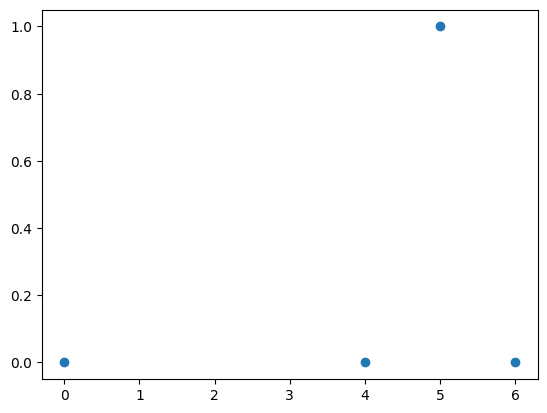

In [5]:
import matplotlib.pyplot as plt

X = np.array([
    [0, 0],
    [4, 0],
    [5, 1],
    [6, 0]
])

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [ ]:
centroids = np.array([
    X[2],
    X[3]
])

def one_kmeans(centroids, X):
    dists = np.array([[np.linalg.norm(x - c) for c in centroids] for x in X])
    assignments = np.argmin(dists, axis=1)
    clusters = [[] for _ in range(len(centroids))]
    for i, a in enumerate(assignments):
        clusters[a].append(X[i])
    centroids = np.array([np.mean(c, axis=0) for c in clusters])
    return dists, assignments, centroids

for i in range(5):
    print(f"Iteration {i}")
    d2, assignments, centroids = one_kmeans(centroids, X)
    print("Dist squared", d2 * d2)
    print("Assignments", assignments)
    print("Centroids", centroids)    

Iteration 0
Dist squared [[ 1.  9.]
 [ 4. 10.]
 [ 0. 10.]
 [10.  0.]
 [13.  1.]
 [ 9.  1.]]
Assignments [0 0 0 1 1 1]
Centroids [[1. 1.]
 [4. 1.]]
Iteration 1
Dist squared [[ 0.  9.]
 [ 1. 10.]
 [ 1. 10.]
 [ 9.  0.]
 [10.  1.]
 [10.  1.]]
Assignments [0 0 0 1 1 1]
Centroids [[1. 1.]
 [4. 1.]]
Iteration 2
Dist squared [[ 0.  9.]
 [ 1. 10.]
 [ 1. 10.]
 [ 9.  0.]
 [10.  1.]
 [10.  1.]]
Assignments [0 0 0 1 1 1]
Centroids [[1. 1.]
 [4. 1.]]
Iteration 3
Dist squared [[ 0.  9.]
 [ 1. 10.]
 [ 1. 10.]
 [ 9.  0.]
 [10.  1.]
 [10.  1.]]
Assignments [0 0 0 1 1 1]
Centroids [[1. 1.]
 [4. 1.]]
Iteration 4
Dist squared [[ 0.  9.]
 [ 1. 10.]
 [ 1. 10.]
 [ 9.  0.]
 [10.  1.]
 [10.  1.]]
Assignments [0 0 0 1 1 1]
Centroids [[1. 1.]
 [4. 1.]]


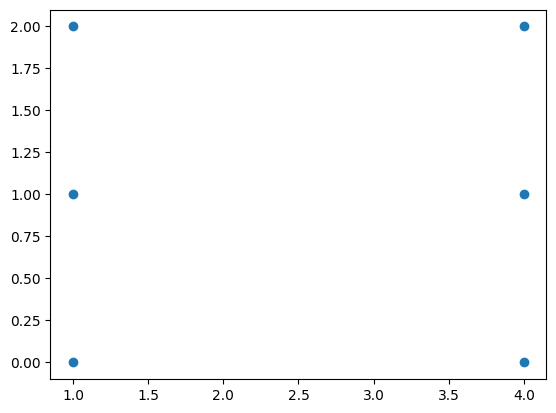

In [17]:
X = np.array([
    [1, 1],
    [1, 2],
    [1, 0],
    [4, 1],
    [4, 2],
    [4, 0]
])
centroids = np.array([X[2], X[4]])

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [ ]:
def error(centroids, X, assignments):
    total = 0
    for i, x in enumerate(X):
        c = centroids[assignments[i]]
        total += np.linalg.norm(x - c) ** 2
    return total

centroids = np.array([X[2], X[4]])

for i in range(5):
    print(f"Iteration {i}")
    d2, assignments, centroids = one_kmeans(centroids, X)
    print("Assignments", assignments)

print("Error", error(centroids, X, assignments))

Iteration 0
Assignments [0 0 0 1 1 1]
Iteration 1
Assignments [0 0 0 1 1 1]
Iteration 2
Assignments [0 0 0 1 1 1]
Iteration 3
Assignments [0 0 0 1 1 1]
Iteration 4
Assignments [0 0 0 1 1 1]
Error 4.0


In [ ]:
centroids = np.array([X[3], X[5]])

for i in range(5):
    print(f"Iteration {i}")
    d2, assignments, centroids = one_kmeans(centroids, X)
    print("Assignments", assignments)

print("Error", error(centroids, X, assignments))

Iteration 0
Assignments [0 0 1 0 0 1]
Iteration 1
Assignments [0 0 1 0 0 1]
Iteration 2
Assignments [0 0 1 0 0 1]
Iteration 3
Assignments [0 0 1 0 0 1]
Iteration 4
Assignments [0 0 1 0 0 1]
Error 14.500000000000002


## Kmeans++

In [22]:
# use the same X
X

array([[1, 1],
       [1, 2],
       [1, 0],
       [4, 1],
       [4, 2],
       [4, 0]])

In [25]:
centroids = np.array([X[0]])
d2 = np.array([[np.linalg.norm(x - c)**2 for c in centroids] for x in X])
probs = d2.min(axis=1)
probs = probs / probs.sum()
print("Dists", d2)
print("Probs", probs)

Dists [[ 0.]
 [ 1.]
 [ 1.]
 [ 9.]
 [10.]
 [10.]]
Probs [0.         0.03225806 0.03225806 0.29032258 0.32258065 0.32258065]


In [27]:
centroids = np.array([X[0], X[4]])
d2, asn, centroids = one_kmeans(centroids, X)
print("Assignments", asn)
print("Centroids", centroids)
error = error(centroids, X, asn)
print("Error", error)

Assignments [0 0 0 1 1 1]
Centroids [[1. 1.]
 [4. 1.]]
Error 4.0


## Fuzzy C-means

In [8]:
X = np.array([
    [0, 0],
    [4, 0],
    [5, 1],
    [6, 0]
])

centroids = np.array([X[2], X[3]])

def one_fcm(centroids, X, p=2):
    # membership matrix
    n = X.shape[0]
    m = len(centroids)
    
    # soft assignment
    c = np.zeros((n, m))
    d = np.array([[np.linalg.norm(x - c)**2 for c in centroids] for x in X])
    for i in range(n):
        flag = -1
        for j in range(m):
            if d[i, j] == 0:
                flag = j
                break
        if flag != -1:
            c[i, flag] = 1
            for j in range(m):
                if j != flag:
                    c[i, j] = 0
        else:
            d_new = 1/ (d[i] ** (1 / (p - 1)))
            s = d_new.sum()
            c[i] = d_new / s
    
    # update centroids
    centroids = c.T @ X / c.sum(axis=0)

    return c, centroids

c, centroids = one_fcm(centroids, X)
print("Membership matrix", c)
print("Centroids", centroids)


Membership matrix [[0.58064516 0.41935484]
 [0.66666667 0.33333333]
 [1.         0.        ]
 [0.         1.        ]]
Centroids [[3.41148325 0.57055215]
 [3.26315789 0.        ]]
